# **DATA WAREHOUSE: COFFEE SHOP SALES**

Proyek ini bertujuan untuk membangun Data Warehouse serta melakukan analisis data terhadap transaksi penjualan coffee shop yang tersebar di berbagai lokasi. Dataset yang digunakan mensimulasikan kondisi dunia nyata dengan mempertimbangkan faktor-faktor seperti waktu transaksi, cuaca, lokasi toko, serta perilaku pelanggan.

Dalam proyek ini dilakukan proses ETL (Extract, Transform, Load) untuk membersihkan dan mentransformasi data, termasuk penanganan missing values, deteksi outlier, validasi data transaksi, serta pembuatan fitur baru (feature engineering). Data kemudian disusun ke dalam struktur Data Warehouse berbasis Star Schema, yang terdiri dari fact table dan beberapa dimension table untuk mendukung analisis yang lebih terstruktur.

Selanjutnya, dilakukan Exploratory Data Analysis (EDA) dan analisis bisnis untuk mengidentifikasi pola penting, seperti kategori produk terlaris, waktu transaksi paling ramai (peak hours), preferensi pelanggan berdasarkan demografi, serta metode pembayaran yang paling sering digunakan.

## **A. Persiapan dan Ekstraksi Data**

In [224]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

# Load data
df = pd.read_csv('coffee_shop_sales.csv')

## **B. Data Understanding**

### **Ringkasan Statistik dan Kualitas Data**

In [225]:
print("Data Overview:")
display(df.head())

Data Overview:


,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount
0,10001,2023-01-01 00:39:39,35,Melbourne,AUS,Mall Kiosk,Coffee,Double Espresso,3.04,1,True,Credit Card,qiyfrwsk,35-44,Female,False,Sunny,22.2,New Year's Day,2.74
1,10002,2023-01-01 01:06:53,25,Manchester,UK,Standalone,Coffee,Single Espresso,2.38,2,False,Debit Card,vf0jqqnv,18-24,Male,False,Sunny,8.7,New Year's Day,4.76
2,10003,2023-01-01 02:56:18,23,Manchester,UK,Standalone,Tea,Large Matcha Latte,4.26,2,False,Mobile Wallet,fcd6mzsg,25-34,Male,False,Sunny,8.7,New Year's Day,8.52
3,10004,2023-01-01 02:58:30,38,Toronto,CAN,Standalone,Coffee,Medium Cappuccino,3.68,2,False,Credit Card,jvu2cgxu,55-64,Female,True,Cloudy,-6.5,New Year's Day,7.36
4,10005,2023-01-01 03:13:53,9,Los Angeles,USA,Mall Kiosk,Coffee,Small Cappuccino,3.42,1,False,Mobile Wallet,po4ljedg,18-24,Male,True,Sunny,12.3,New Year's Day,3.42


In [226]:
print("\nInformasi Dataset:")
print(df.info())


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      20000 non-null  int64  
 1   timestamp           20000 non-null  object 
 2   store_id            20000 non-null  int64  
 3   city                20000 non-null  object 
 4   country             20000 non-null  object 
 5   store_type          20000 non-null  object 
 6   product_category    20000 non-null  object 
 7   product_name        20000 non-null  object 
 8   unit_price          20000 non-null  float64
 9   quantity            20000 non-null  int64  
 10  discount_applied    20000 non-null  bool   
 11  payment_method      20000 non-null  object 
 12  customer_id         20000 non-null  object 
 13  customer_age_group  18924 non-null  object 
 14  customer_gender     18928 non-null  object 
 15  loyalty_member      20000 non-nul

Pada gambar terlihat bahwa dataset ini terdiri dari 20.000 baris dan 20 kolom dengan kombinasi tipe data numerik, kategorikal, boolean, dan satu kolom waktu (`timestamp`) yang masih bertipe object. Secara umum, dataset ini sudah cukup bersih karena sebagian besar kolom memiliki nilai lengkap, namun terdapat beberapa kolom dengan missing values seperti `customer_age_group`, `customer_gender`, `weather_condition`, dan `temperature_c` (sekitar 5% data hilang), serta `holiday_name` yang memiliki tingkat kekosongan sangat tinggi (hampir 98%). Pada tahap data transformation, kolom dengan banyak missing seperti `holiday_name` sebaiknya diubah menjadi fitur boolean (misalnya `is_holiday`), sementara kolom lain dapat diisi dengan nilai modus atau label seperti “Unknown”.

Selanjutnya, kolom `timestamp` perlu dikonversi ke tipe datetime agar dapat diekstrak menjadi fitur tambahan seperti hari, bulan, jam, atau penanda akhir pekan yang berguna untuk analisis pola transaksi. Kolom kategorikal seperti `city`, `store_type`, `product_category`, dan `payment_method` perlu dilakukan encoding, baik menggunakan one-hot encoding untuk kategori kecil maupun label encoding untuk kategori dengan banyak variasi seperti `product_name`. Sementara itu, kolom boolean seperti `discount_applied` dan `loyalty_member` dapat diubah menjadi nilai numerik agar kompatibel dengan model machine learning.

Untuk kolom numerik seperti `unit_price`, `quantity`, dan `total_amount`, perlu dilakukan pengecekan outlier serta normalisasi atau standardisasi jika akan digunakan dalam pemodelan. Selain itu, feature engineering dapat dilakukan dengan membuat fitur baru seperti total harga hasil perkalian `unit_price` dan `quantity`, indikator akhir pekan, atau segmentasi pelanggan berdasarkan usia dan status loyalitas. Terakhir, kolom yang tidak memiliki nilai analitis seperti `transaction_id` dapat dihapus, serta perlu dilakukan pengecekan konsistensi data dan duplikasi untuk memastikan kualitas dataset sebelum masuk ke tahap analisis atau pemodelan lebih lanjut.


In [227]:
print("\nStatistik Deskriptif:")
display(df.describe())


Statistik Deskriptif:


,transaction_id,store_id,unit_price,quantity,temperature_c,total_amount
count,20000.000000,20000.000000,20000.000000,20000.00000,19022.000000,20000.000000
mean,20000.500000,23.072950,4.049521,1.71265,13.556550,6.850464
std,5773.647028,13.097332,1.982984,1.10808,8.184881,5.989221
min,10001.000000,1.000000,1.640000,1.00000,-11.000000,1.310000
25%,15000.750000,12.000000,2.820000,1.00000,7.600000,3.360000
50%,20000.500000,23.000000,3.690000,1.00000,14.600000,4.920000
75%,25000.250000,34.000000,4.750000,2.00000,19.800000,8.200000
max,30000.000000,45.000000,18.750000,9.00000,32.600000,112.000000


Statistik deskriptif pada dataset menunjukkan bahwa seluruh kolom numerik seperti `unit_price`, `quantity`, dan `total_amount` memiliki 20.000 data lengkap, kecuali `temperature_c` yang sedikit lebih rendah (19.022 data), menandakan adanya missing values. Rata-rata harga produk (`unit_price`) sekitar 4.05 dengan variasi yang cukup besar hingga maksimum 18.75, sedangkan jumlah pembelian (`quantity`) rata-rata sekitar 1.71 dengan nilai maksimum 9, yang mengindikasikan sebagian besar transaksi melibatkan pembelian dalam jumlah kecil. Total transaksi (`total_amount`) memiliki rata-rata 6.85 namun terdapat nilai maksimum yang sangat tinggi (112), sehingga perlu diwaspadai adanya outlier. Sementara itu, suhu (`temperature_c`) memiliki rentang dari -11 hingga 32.6 derajat, menunjukkan variasi kondisi lingkungan yang cukup luas. Secara keseluruhan, distribusi data terlihat cukup normal pada beberapa variabel (median mendekati mean), namun tetap diperlukan pengecekan lebih lanjut terhadap outlier dan penanganan missing values sebelum dilakukan analisis lanjutan atau pemodelan.


In [228]:
print("\nJumlah Missing Values:")
print(df.isnull().sum())


Jumlah Missing Values:
transaction_id            0
timestamp                 0
store_id                  0
city                      0
country                   0
store_type                0
product_category          0
product_name              0
unit_price                0
quantity                  0
discount_applied          0
payment_method            0
customer_id               0
customer_age_group     1076
customer_gender        1072
loyalty_member            0
weather_condition       978
temperature_c           978
holiday_name          19665
total_amount              0
dtype: int64


Berdasarkan informasi jumlah missing values, sebagian besar kolom dalam dataset sudah lengkap tanpa nilai kosong, namun terdapat beberapa kolom yang perlu perhatian khusus yaitu `customer_age_group` (1076 data hilang), `customer_gender` (1072), `weather_condition` (978), `temperature_c` (978), dan terutama `holiday_name` yang memiliki missing sangat tinggi (19.665 dari 20.000 data). Hal ini menunjukkan bahwa `holiday_name` kemungkinan besar hanya relevan pada kondisi tertentu (misalnya hari libur), sehingga lebih efektif jika diubah menjadi fitur indikator seperti `is_holiday`. Untuk kolom lain dengan missing sekitar 5%, penanganan dapat dilakukan dengan imputasi menggunakan modus (untuk data kategorikal) atau nilai rata-rata/median (untuk numerik seperti `temperature_c`), atau dengan memberi label “Unknown”. Secara keseluruhan, dataset ini tergolong bersih dan hanya memerlukan sedikit penanganan missing values sebelum dapat digunakan lebih lanjut dalam analisis atau pemodelan.


In [229]:
df[df.duplicated()]

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount


Setelah dilakukan pengecekan tidak terdapat nilai duplikat pada dataset ini.

### **Distribusi Variabel Numerik**

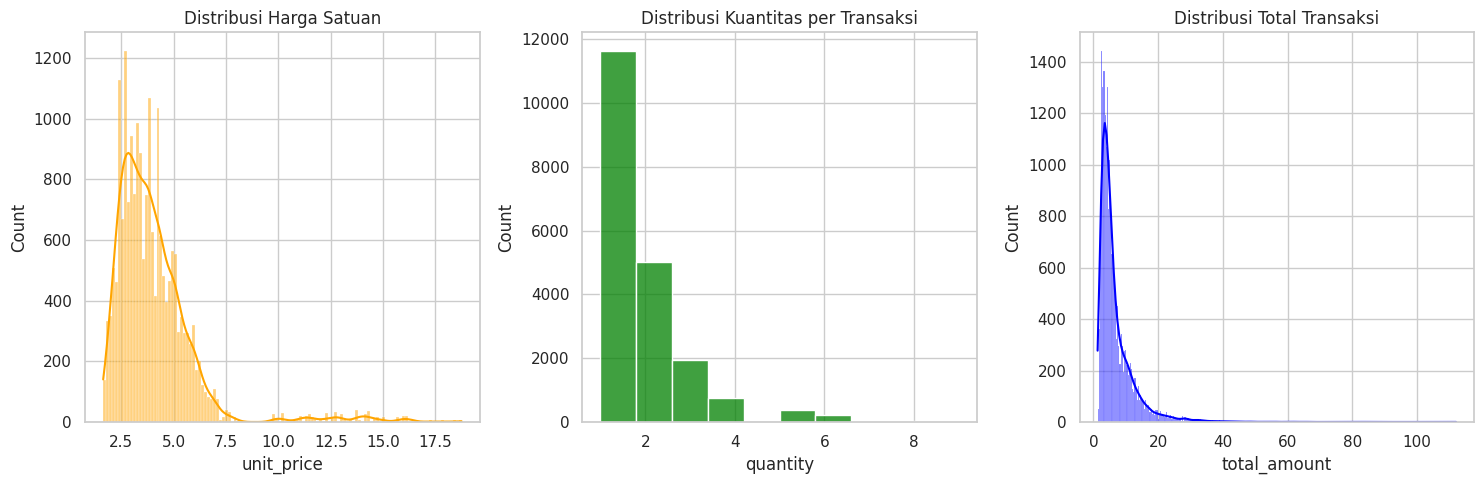

In [230]:
plt.figure(figsize=(15, 5))

# Distribusi Unit Price
plt.subplot(1, 3, 1)
sns.histplot(df['unit_price'], kde=True, color='orange')
plt.title('Distribusi Harga Satuan')

# Distribusi Quantity
plt.subplot(1, 3, 2)
sns.histplot(df['quantity'], bins=10, color='green')
plt.title('Distribusi Kuantitas per Transaksi')

# Distribusi Total Amount
plt.subplot(1, 3, 3)
sns.histplot(df['total_amount'], kde=True, color='blue')
plt.title('Distribusi Total Transaksi')

plt.tight_layout()
plt.show()

Berdasarkan ketiga grafik distribusi, terlihat pola yang cukup konsisten pada perilaku transaksi.

Distribusi **harga satuan (unit_price)** menunjukkan bentuk right-skewed (miring ke kanan), di mana sebagian besar produk berada pada rentang harga rendah hingga menengah (sekitar 2–6), namun terdapat sejumlah kecil produk dengan harga tinggi hingga di atas 10 yang berpotensi sebagai outlier atau produk premium.

Distribusi **kuantitas (quantity)** memperlihatkan bahwa mayoritas transaksi hanya membeli 1–2 item, dengan frekuensi yang menurun drastis untuk jumlah pembelian yang lebih besar, sehingga menunjukkan pola pembelian konsumen yang cenderung dalam jumlah kecil.

Sementara itu, distribusi **total transaksi (total_amount)** juga sangat right-skewed, dengan sebagian besar transaksi bernilai rendah, tetapi terdapat beberapa transaksi dengan nilai sangat tinggi (hingga di atas 100) yang mengindikasikan adanya outlier atau pembelian dalam jumlah besar/produk mahal. Secara keseluruhan, ketiga grafik ini mengindikasikan bahwa data tidak berdistribusi normal, memiliki ekor panjang (long tail), dan memerlukan penanganan khusus seperti transformasi log atau penanganan outlier sebelum digunakan dalam analisis lanjutan atau pemodelan.


### **Analisis Kategori Produk dan Penjualan**

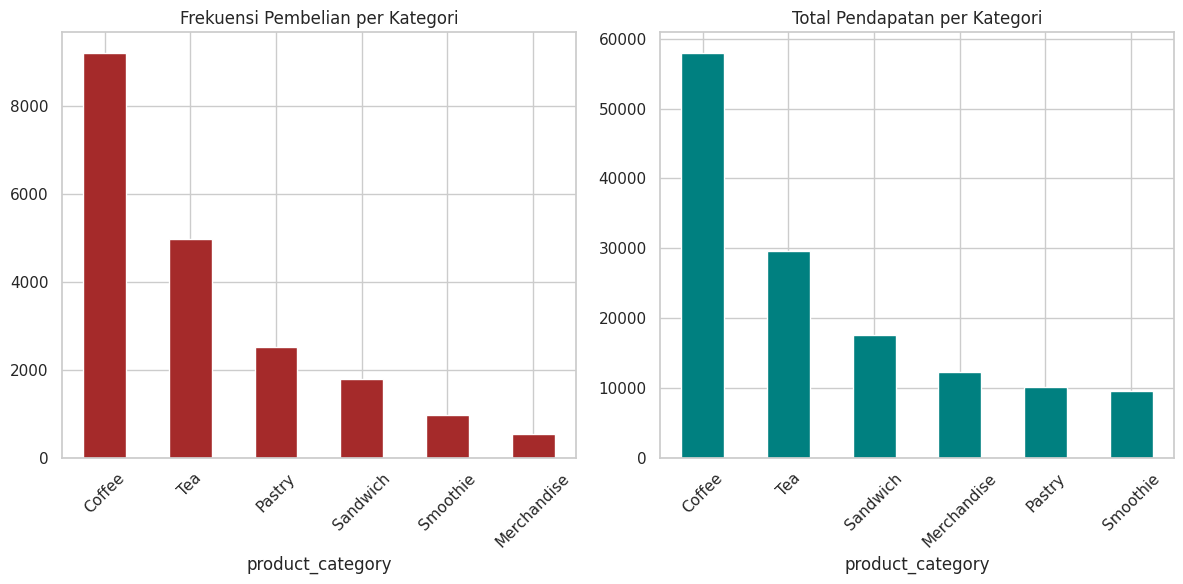

In [231]:
plt.figure(figsize=(12, 6))

# Produk Terpopuler berdasarkan Frekuensi
plt.subplot(1, 2, 1)
df['product_category'].value_counts().plot(kind='bar', color='brown')
plt.title('Frekuensi Pembelian per Kategori')
plt.xticks(rotation=45)

# Total Pendapatan per Kategori
plt.subplot(1, 2, 2)
df.groupby('product_category')['total_amount'].sum().sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title('Total Pendapatan per Kategori')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Berdasarkan kedua grafik, terlihat bahwa kategori **Coffee** mendominasi baik dari sisi frekuensi pembelian maupun total pendapatan, yang menunjukkan bahwa produk ini merupakan kontributor utama bisnis. Kategori **Tea** berada di posisi kedua dengan jumlah transaksi dan pendapatan yang cukup signifikan, diikuti oleh **Pastry** dan **Sandwich** yang memiliki frekuensi pembelian lebih rendah namun masih memberikan kontribusi pendapatan yang cukup stabil. Menariknya, kategori seperti **Merchandise** dan **Smoothie** memiliki frekuensi pembelian yang relatif rendah, tetapi tetap menghasilkan pendapatan yang tidak terlalu kecil, yang mengindikasikan kemungkinan harga produk yang lebih tinggi atau margin yang lebih besar. Secara keseluruhan, pola ini menunjukkan bahwa produk minuman (terutama coffee dan tea) menjadi driver utama volume dan revenue, sementara kategori lain berperan sebagai pelengkap, sehingga strategi bisnis dapat difokuskan pada optimalisasi produk utama serta peningkatan penjualan kategori dengan performa lebih rendah.


### **Analisis Demografi Pelanggan**

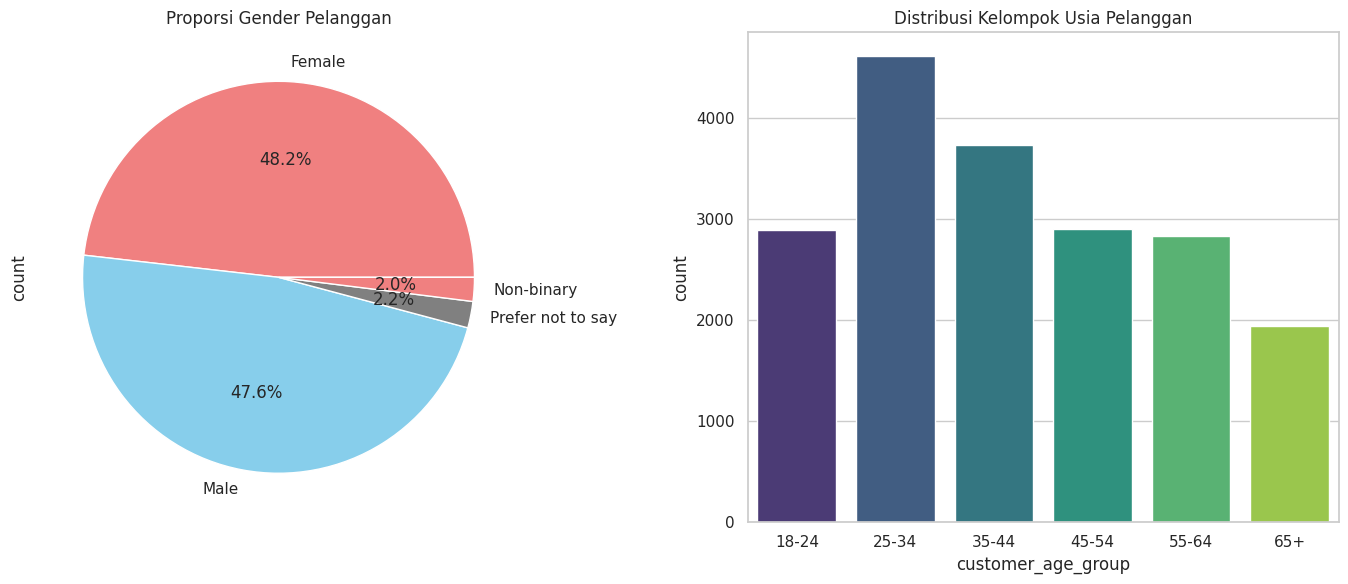

In [232]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Distribusi Gender Pelanggan
df['customer_gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[0], colors=['lightcoral', 'skyblue', 'gray'])
ax[0].set_title('Proporsi Gender Pelanggan')

# Distribusi Kelompok Usia
sns.countplot(data=df, x='customer_age_group', order=sorted(df['customer_age_group'].dropna().unique()), ax=ax[1], palette='viridis')
ax[1].set_title('Distribusi Kelompok Usia Pelanggan')

plt.tight_layout()
plt.show()

Berdasarkan visualisasi, proporsi gender pelanggan terlihat cukup seimbang antara **Female (48.2%)** dan **Male (47.6%)**, sementara kategori **Non-binary (2.0%)** dan **Prefer not to say (2.2%)** memiliki porsi yang sangat kecil, sehingga dapat disimpulkan bahwa tidak ada dominasi gender yang signifikan dalam dataset ini. Sementara itu, distribusi kelompok usia menunjukkan bahwa pelanggan paling banyak berasal dari rentang usia **25–34 tahun**, diikuti oleh **35–44 tahun**, yang menandakan bahwa mayoritas konsumen berada pada usia produktif. Kelompok usia muda **18–24** dan usia menengah ke atas seperti **45–54** serta **55–64** memiliki jumlah yang relatif seimbang namun lebih rendah, sedangkan kelompok **65+** merupakan yang paling sedikit. Secara keseluruhan, pola ini menunjukkan bahwa target utama bisnis cenderung adalah pelanggan usia dewasa muda dengan distribusi gender yang merata, sehingga strategi pemasaran dapat difokuskan pada segmen usia tersebut tanpa perlu diferensiasi yang terlalu kuat berdasarkan gender.


### **Hubungan Antar Variabel**

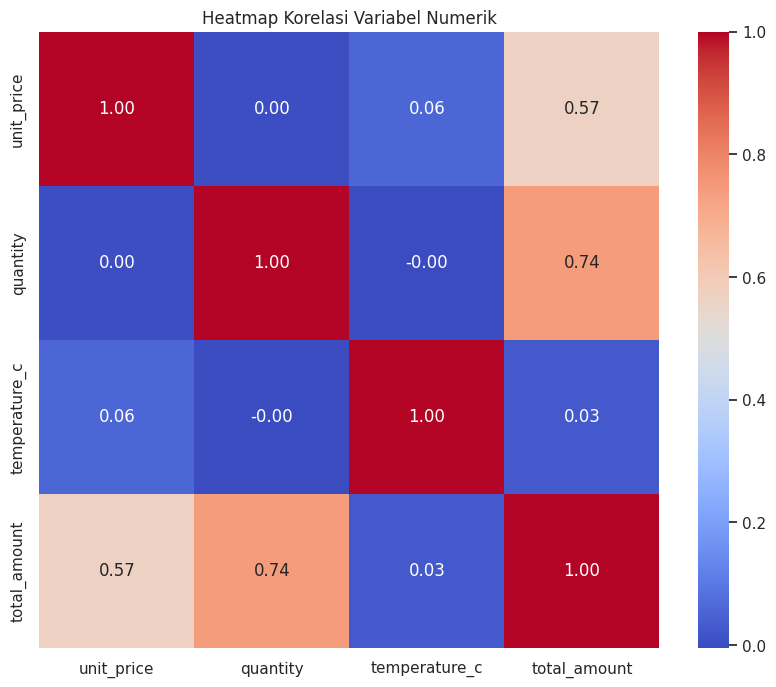

In [233]:
plt.figure(figsize=(10, 8))
correlation_matrix = df[['unit_price', 'quantity', 'temperature_c', 'total_amount']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Variabel Numerik')
plt.show()

Berdasarkan heatmap, terlihat bahwa variabel yang paling berpengaruh terhadap `total_amount` adalah **quantity (0.74)** dan **unit_price (0.57)**, yang menunjukkan korelasi positif cukup kuat hingga sedang—artinya semakin banyak jumlah barang yang dibeli dan semakin tinggi harga satuan, maka total transaksi akan meningkat secara signifikan. Sementara itu, `temperature_c` hampir tidak memiliki hubungan dengan variabel lain, termasuk `total_amount` (0.03), sehingga dapat dianggap tidak relevan secara langsung dalam memengaruhi nilai transaksi. Selain itu, tidak terdapat korelasi berarti antara `unit_price` dan `quantity` (mendekati 0), yang mengindikasikan bahwa harga produk tidak memengaruhi jumlah pembelian dalam dataset ini. Secara keseluruhan, insight ini menegaskan bahwa faktor utama pembentuk pendapatan adalah kombinasi harga dan kuantitas, sedangkan variabel eksternal seperti suhu tidak memberikan dampak signifikan.


## **C. Proses Transformasi Data**

### **Data Cleaning**

In [234]:
df['customer_age_group'].fillna('Unknown', inplace=True)
df['customer_gender'].fillna('Unknown', inplace=True)
df['weather_condition'].fillna('Unknown', inplace=True)
df['temperature_c'].fillna(df['temperature_c'].mean(), inplace=True)

df['is_holiday'] = df['holiday_name'].notnull().astype(int)
df.drop(columns=['holiday_name'], inplace=True)

Pada kolom kategorikal seperti customer_age_group, customer_gender, dan weather_condition, nilai kosong diisi dengan label "Unknown" agar tidak kehilangan data dan tetap mempertahankan informasi kategori, sedangkan pada kolom numerik temperature_c digunakan nilai rata-rata (mean) karena lebih representatif untuk data kontinu. Selanjutnya, kolom holiday_name yang memiliki banyak missing tidak digunakan secara langsung, melainkan diubah menjadi fitur baru is_holiday dalam bentuk biner (0 dan 1) untuk menandakan apakah transaksi terjadi saat hari libur atau tidak, sehingga lebih sederhana dan relevan untuk analisis. Setelah itu, kolom holiday_name dihapus karena sudah tidak diperlukan, sehingga dataset menjadi lebih bersih, efisien, dan siap untuk tahap analisis lanjutan atau pembangunan data warehouse.

### **Outlier Handling**

In [235]:
Q1 = df['total_amount'].quantile(0.25)
Q3 = df['total_amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['total_amount'] = df['total_amount'].clip(lower, upper)

kode diatas merupakan proses penangan outlier pada kolom total_amount.

### **Validasi Data**

In [236]:
df['calculated_total'] = df['unit_price'] * df['quantity']
df['selisih'] = df['total_amount'] - df['calculated_total']

In [237]:
(df['selisih'] != 0).sum()

np.int64(4028)

In [238]:
df.groupby('discount_applied')['selisih'].mean()

,selisih
discount_applied,
False,-0.553252
True,-1.273689


Hasil analisis menunjukkan bahwa terdapat perbedaan antara total transaksi dan hasil perhitungan harga dikali jumlah. Perbedaan ini lebih besar pada transaksi dengan diskon, yang mengindikasikan bahwa diskon merupakan faktor utama penyebab selisih tersebut. Namun, pada transaksi tanpa diskon masih ditemukan selisih kecil, yang kemungkinan disebabkan oleh pembulatan harga atau faktor tambahan lainnya.

### **Feature Engineering**

In [239]:
df['transaction_size'] = df['quantity'].apply(
    lambda x: 'small' if x == 1 else 'medium' if x <= 3 else 'large'
)

df['price_category'] = pd.cut(df['unit_price'],
                             bins=[0,3,6,100],
                             labels=['low','medium','high'])

Kode tersebut digunakan membuat fitur baru agar data lebih mudah dianalisis dan memberikan insight yang lebih bermakna. kedua fitur ini bertujuan untuk menyederhanakan data numerik menjadi kategori yang lebih interpretatif sehingga memudahkan analisis bisnis, visualisasi, dan pemodelan.

### **Time Transformation**

In [240]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['weekday'] = df['timestamp'].dt.day_name()

df['is_weekend'] = df['weekday'].isin(['Saturday','Sunday']).astype(int)

transformasi data waktu (time-based feature engineering) agar kolom timestamp yang awalnya berupa teks dapat diolah menjadi informasi yang lebih berguna untuk analisis. Pertama, pd.to_datetime() mengubah kolom timestamp menjadi tipe datetime sehingga bisa diekstrak komponennya. Selanjutnya, dibuat beberapa fitur baru yaitu hour (jam transaksi), day (tanggal), month (bulan), dan weekday (nama hari), yang berguna untuk menganalisis pola transaksi berdasarkan waktu, seperti jam ramai atau hari tertentu. Terakhir, dibuat fitur is_weekend yang bernilai 1 jika transaksi terjadi pada hari Sabtu atau Minggu, dan 0 jika tidak, sehingga memudahkan analisis perbandingan antara hari kerja dan akhir pekan. Secara keseluruhan, kode ini bertujuan untuk mengubah data waktu menjadi fitur yang lebih informatif dan siap digunakan dalam analisis tren maupun pengambilan keputusan bisnis.

## **C. LOAD (DATA WAREHOUSE)**

### **Fact Table**

Membuat fact table (fact_sales) dalam konsep Data Warehouse (Star Schema) dengan mengambil kolom-kolom penting dari dataset utama (df) yang berisi data transaksi. Kolom yang dipilih seperti transaction_id, timestamp, product_name, quantity, unit_price, dan total_amount merupakan atribut utama yang menggambarkan kejadian transaksi (event), sehingga cocok dijadikan fact table karena berisi data numerik yang bisa diukur (measure) seperti jumlah dan total penjualan. Tujuan dari pembuatan fact_sales ini adalah untuk memisahkan data inti transaksi dari atribut lain (seperti customer, produk, waktu, dan lokasi) yang nantinya akan ditempatkan di dimension table, sehingga struktur data menjadi lebih terorganisir, efisien, dan optimal untuk analisis serta query dalam Data Warehouse.

In [241]:
fact_sales = df[['transaction_id','timestamp','product_name',
                 'quantity','unit_price','total_amount']]

### **Dimension Table**

untuk membuat dimension tables dalam struktur Data Warehouse (Star Schema) dengan mengambil atribut-atribut deskriptif dari dataset utama (df) dan menghilangkan data duplikat menggunakan .drop_duplicates(). Setiap tabel dimensi memiliki fungsi spesifik: dim_product menyimpan informasi produk seperti nama dan kategori, dim_customer berisi data pelanggan seperti ID, gender, usia, dan status loyalitas, dim_time menyimpan informasi waktu yang sudah dipecah (jam, hari, bulan, dll.) untuk analisis temporal, dan dim_store berisi informasi lokasi seperti kota, negara, dan tipe toko. Penggunaan .drop_duplicates() penting agar setiap entitas hanya muncul sekali (tidak redundan), sehingga struktur data menjadi lebih efisien dan terorganisir. Secara keseluruhan, pemisahan ini bertujuan untuk mendukung analisis yang lebih cepat, fleksibel, dan scalable dalam Data Warehouse, di mana fact table akan terhubung ke dimension tables melalui atribut terkait.

In [242]:
dim_product = df[['product_name','product_category']].drop_duplicates()
dim_customer = df[['customer_id','customer_gender',
                   'customer_age_group','loyalty_member']].drop_duplicates()
dim_time = df[['timestamp','hour','day','month','weekday','is_weekend']].drop_duplicates()
dim_store = df[['city','country','store_type']].drop_duplicates()


### **Save**

Menyimpan fact table dan dimension tables.

In [243]:
import os

os.makedirs('data_warehouse/fact', exist_ok=True)
os.makedirs('data_warehouse/dimension', exist_ok=True)

In [244]:
fact_sales.to_csv('data_warehouse/fact/fact_sales.csv', index=False)

In [245]:
dim_product.to_csv('data_warehouse/dimension/dim_product.csv', index=False)

dim_customer.to_csv('data_warehouse/dimension/dim_customer.csv', index=False)

dim_time.to_csv('data_warehouse/dimension/dim_time.csv', index=False)

dim_store.to_csv('data_warehouse/dimension/dim_store.csv', index=False)

In [246]:
df.to_csv('data_warehouse/coffe_shop_sales_cleaned_data.csv', index=False)

## **D. Analisis Data**

### **Revenue per Product**

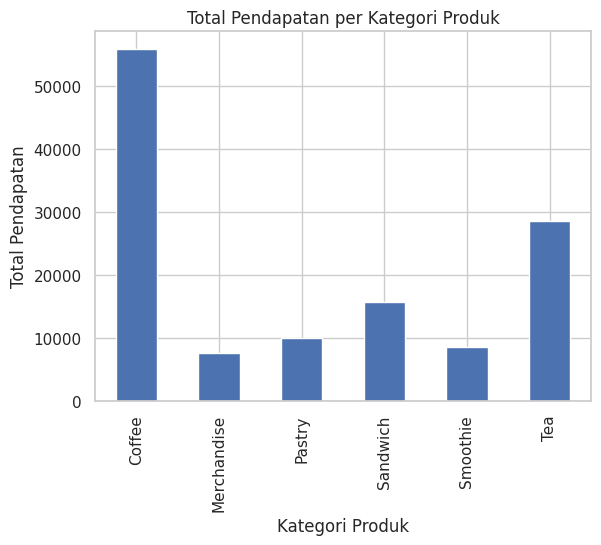

In [247]:
df.groupby('product_category')['total_amount'].sum().plot(kind='bar')
plt.title('Total Pendapatan per Kategori Produk')
plt.xlabel('Kategori Produk')
plt.ylabel('Total Pendapatan')

plt.show()

Berdasarkan grafik, terlihat bahwa kategori Coffee memiliki jumlah pendapatan yang paling tinggi secara signifikan dibandingkan kategori lainnya, sehingga dapat disimpulkan bahwa coffee merupakan produk utama dan menjadi driver utama bisnis. Di posisi kedua terdapat Tea, yang juga menunjukkan kontribusi cukup besar, meskipun masih jauh di bawah coffee. Kategori seperti Sandwich, Pastry, dan Smoothie berada di tingkat menengah dengan performa yang relatif stabil, sedangkan Merchandise memiliki nilai paling rendah, menunjukkan bahwa produk ini kurang diminati atau hanya sebagai pelengkap.

Secara bisnis, hal ini mengindikasikan bahwa strategi sebaiknya difokuskan pada optimalisasi penjualan coffee (misalnya variasi menu, promo, atau bundling), serta meningkatkan performa kategori lain seperti pastry atau sandwich melalui cross-selling (misalnya paket coffee + pastry). Sementara itu, kategori dengan performa rendah seperti merchandise perlu dievaluasi kembali, apakah perlu ditingkatkan strateginya atau justru tidak menjadi prioritas utama.

### **Peak Hour**

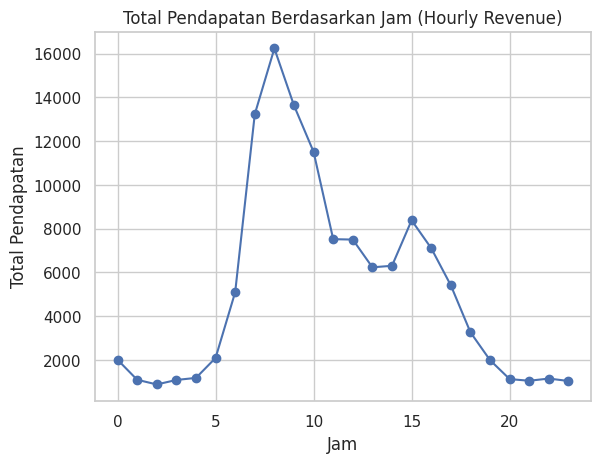

In [248]:
df.groupby('hour')['total_amount'].sum().plot(marker='o')
plt.title('Total Pendapatan Berdasarkan Jam (Hourly Revenue)')
plt.xlabel('Jam')
plt.ylabel('Total Pendapatan')

plt.show()

Berdasarkan grafik, terlihat pola yang jelas bahwa aktivitas transaksi meningkat tajam pada pagi hingga siang hari, dengan puncak tertinggi terjadi sekitar **jam 08.00–09.00**, yang menunjukkan waktu paling ramai (peak hours) kemungkinan saat orang membeli kopi sebelum memulai aktivitas kerja. Setelah itu, terjadi penurunan bertahap hingga siang hari, meskipun masih cukup tinggi hingga sekitar jam 10.00–11.00. Pada sore hari sekitar **jam 15.00** terlihat kenaikan kecil (secondary peak), yang kemungkinan mencerminkan waktu istirahat atau “coffee break”. Sementara itu, pada malam hari (di atas jam 18.00), jumlah transaksi menurun drastis dan relatif rendah. Secara bisnis, insight ini menunjukkan bahwa operasional dan strategi penjualan sebaiknya difokuskan pada pagi hari sebagai waktu utama, misalnya dengan meningkatkan stok, mempercepat layanan, atau memberikan promo khusus pagi, serta memanfaatkan peluang di sore hari dengan promosi tambahan untuk meningkatkan penjualan.


### **Customer Analysis**

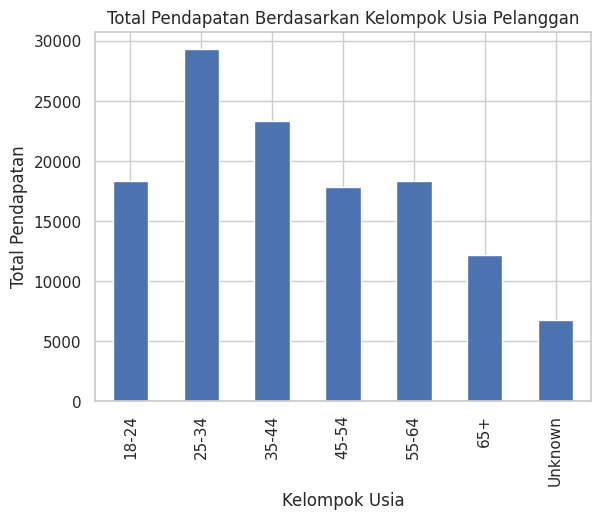

In [249]:
df.groupby('customer_age_group')['total_amount'].sum().plot(kind='bar')

plt.title('Total Pendapatan Berdasarkan Kelompok Usia Pelanggan')
plt.xlabel('Kelompok Usia')
plt.ylabel('Total Pendapatan')

plt.show()

Berdasarkan grafik distribusi kelompok usia pelanggan, terlihat bahwa segmen usia 25–34 tahun merupakan kelompok dengan kontribusi terbesar, diikuti oleh usia 35–44 tahun, yang menunjukkan bahwa mayoritas pelanggan berada pada usia produktif dan aktif secara ekonomi. Kelompok usia 18–24, 45–54, dan 55–64 memiliki kontribusi yang relatif stabil namun lebih rendah, sedangkan usia 65+ merupakan yang paling sedikit. Selain itu, terdapat kategori Unknown yang cukup signifikan, menandakan adanya data yang belum teridentifikasi. Secara bisnis, hal ini menunjukkan bahwa target utama coffee shop adalah pelanggan dewasa muda, sehingga strategi pemasaran, produk, dan promosi sebaiknya difokuskan pada gaya hidup dan preferensi kelompok usia tersebut, sementara segmen usia lainnya dapat dikembangkan sebagai pasar tambahan.

### **Payment Method**

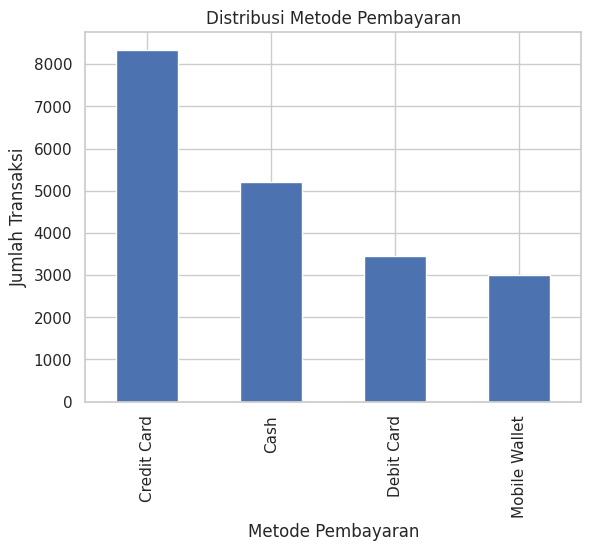

In [250]:
df['payment_method'].value_counts().sort_values(ascending=False).plot(kind='bar')

plt.title('Distribusi Metode Pembayaran')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Transaksi')

plt.show()

Berdasarkan grafik, terlihat bahwa metode pembayaran Credit Card merupakan yang paling dominan digunakan oleh pelanggan, diikuti oleh Cash, kemudian Debit Card, dan yang paling rendah adalah Mobile Wallet. Hal ini menunjukkan bahwa pelanggan cenderung lebih nyaman menggunakan kartu kredit untuk transaksi, kemungkinan karena kemudahan, promo, atau sistem pembayaran yang lebih praktis. Meskipun pembayaran digital seperti mobile wallet sudah ada, penggunaannya masih relatif rendah, yang bisa menjadi peluang bagi bisnis untuk meningkatkan adopsi melalui promosi khusus atau integrasi pembayaran yang lebih menarik. Secara keseluruhan, insight ini menunjukkan pentingnya memastikan sistem pembayaran kartu kredit tetap optimal, sambil mendorong pertumbuhan metode pembayaran digital sebagai potensi peningkatan di masa depan.